# Homework 7: Bootstrap and Resampling

**Reading**: 
* [Estimation](https://www.inferentialthinking.com/chapters/13/Estimation.html)

Please complete this notebook by filling in the cells provided. Before you begin, execute the following cell. Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. 

In [1]:
# Run this cell to set up the notebook, but please don't change it.
import numpy as np
from datascience import *

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## 1. Preliminaries
The British Royal Air Force wanted to know how many warplanes the Germans had (some number `N`, which is a *parameter*), and they needed to estimate that quantity knowing only a random sample of the planes' serial numbers (from 1 to `N`). We know that the Germans' warplanes are labeled consecutively from 1 to `N`, so `N` would be the total number of warplanes they have. 

We normally investigate the random variation among our estimates by simulating a sampling procedure from the population many times and computing estimates from each sample that we generate.  In real life, if the British Royal Air Force (RAF) had known what the population looked like, they would have known `N` and would not have had any reason to think about random sampling. However, they didn't know what the population looked like, so they couldn't have run the simulations that we normally do. 

Simulating a sampling procedure many times was a useful exercise in *understanding random variation* for an estimate, but it's not as useful as a tool for practical data analysis.

Let's flip that sampling idea on its head to make it practical. **Given *just* a random sample of serial numbers, we'll estimate `N`, and then we'll use simulation to find out how accurate our estimate probably is, without ever looking at the whole population.**  This is an example of *statistical inference*.

We (the RAF in World War II) want to know the number of warplanes fielded by the Germans.  That number is `N`.  The warplanes have serial numbers from 1 to `N`, so `N` is also equal to the largest serial number on any of the warplanes.

We only see a small number of serial numbers (assumed to be a random sample with replacement from among all the serial numbers), so we have to use estimation.

**Question 1.1.** Is `N` a population parameter or a statistic?  If we use our random sample to compute a number that is an estimate of `N`, is that a population parameter or a statistic?

Set `N` and `N_estimate` to either the string `"parameter"` or `"statistic"` to indicate whether each value is a parameter or a statistic.

In [2]:
N = "parameter"
N_estimate = "statistic"

To make the situation realistic, we're going to hide the true number of warplanes from you.  You'll have access only to this random sample:

In [3]:
observations = Table.read_table("../../shared/Data/serial_numbers.csv")
num_observations = observations.num_rows
observations

serial number
38
64
51
4
84
36
83
56
25
79


**Question 1.2.** The average of the sample is about half of `N`. So one way to estimate `N` is to take twice the mean of the serial numbers we see. Write a function that computes that statistic.  It should take as its argument an array of serial numbers and return twice their mean.  Call the function `mean_based_estimator`.  

After that, use the function and the `observations` table to compute an estimate of `N` called `mean_based_estimate`.

In [4]:
def mean_based_estimator(nums):
    return 2 * np.mean(nums)

mean_based_estimate = mean_based_estimator(observations.column("serial number"))
mean_based_estimate

123.17647058823529

## 2. Resampling
When we try to find the value of a population parameter, we ideally would like to use the whole population. However, we often only have access to one sample and we must use that to estimate the parameter instead.

Here, we would like to use the population of serial numbers to draw more samples and run a simulation about estimates of `N`.  But we still only have our sample.  So, we **use our sample in place of the population** to run the simulation. We resample from our original sample with replacement as many times as there are elements in the original sample. This resampling technique is called *bootstrapping*. 

Note that in order for bootstrapping to work well, you must start with a large, random sample. Then the Law of Large Numbers says that with high probability, your sample is representative of the population.

**Question 2.1.** Write a function called `simulate_resample`. The function should take one argument `tbl`, which is a table like `observations`. The function should generate a resample from the observed serial numbers in `tbl`.

In [5]:
def simulate_resample(tbl):
    return tbl.sample(with_replacement=True)

simulate_resample(observations) # Don't delete this line

serial number
64
4
83
15
15
51
83
83
64
64


We'll use many resamples at once to see what estimates typically look like.  However, we don't often pay attention to single resamples, so it's easy to misunderstand them.  Let's first answer some questions about our resample.

**Question 2.2.** Which of the following statements are true?

1. The resample can contain serial numbers that are not in the original sample. 
2. The original sample can contain serial numbers that are not in the resample.
3. Because the sample size is small, the histogram of the resample might look very different from the histogram of the original sample. 
4. The resample has either zero, one, or more than one copy of each serial number.
5. The original sample has exactly one copy of each serial number for every German plane.
6. The resample has exactly the same sample size as the original sample.

Assign `true_statements` to an array of the number(s) corresponding to correct statements.

*Note:* The "original sample" refers to `observations`, and the "resample" refers the output of one call of `simulate_resample()`. 

In [6]:
true_statements = make_array(2, 3, 4, 6)

Now let's write a function to do many resamples at once.

**Question 2.3.** Write a function called `sample_estimates`.  It should take 3 arguments:
1. `serial_num_tbl`: A table from which the data should be sampled.  The table will look like `observations`. 
2. `statistic`: A *function* that takes in an array of serial numbers as its argument and computes a statistic from the array (i.e. returns a calculated number). 
3. `num_replications`: The number of simulations to perform.

*Hint: You should use the function `simulate_resample` which you defined in Question 2.1*

The function should simulate many samples **with replacement** from the given table. For each of those samples, it should compute the statistic on that sample. Then it should **return an array** containing each of those statistics.  The code below provides an example use of your function and describes how you can verify that you've written it correctly.

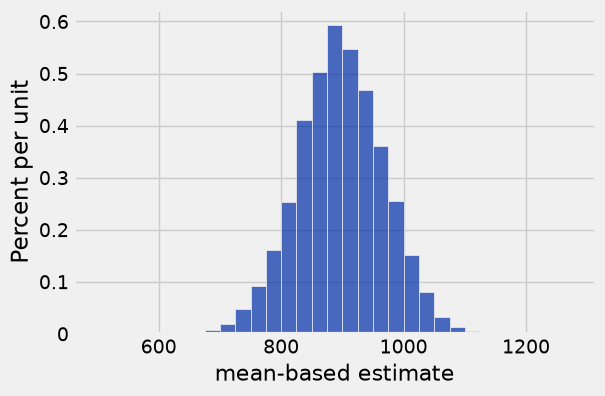

In [7]:
def sample_estimates(serial_num_tbl, statistic, num_replications):
    estimates = make_array()
    for i in np.arange(num_replications):
        resample = simulate_resample(serial_num_tbl)
        estimates = np.append(estimates, statistic(resample.column("serial number")))
    return estimates

# DON'T CHANGE THE CODE BELOW THIS COMMENT!
# This is just an example to test your function.
# This should generate an empirical histogram of twice-mean-based estimates
# of N from samples of size 50 if N is 1000.  This should be a bell-shaped
# curve centered at roughly 900 with most of its mass in [800, 1000].  To verify your
# answer, make sure that's what you see!
population = Table().with_column("serial number", np.arange(1, 1000+1))
one_sample = Table.read_table("../../shared/Data/one_sample.csv") #This is a sample from the population table
example_estimates = sample_estimates(
    one_sample,
    mean_based_estimator,
    10000)
Table().with_column("mean-based estimate", example_estimates).hist(bins=np.arange(500, 1300, 25))

Now we can go back to the sample we actually observed (the table `observations`) and estimate how much our mean-based estimate of `N` would have varied from sample to sample.

**Question 2.4.** Using the bootstrap and the sample `observations`, simulate the approximate distribution of *mean-based estimates* of `N`.  Use 5000 replications and save the estimates in an array called `bootstrap_mean_based_estimates`.  

We have provided code that plots a histogram, allowing you to visualize the simulated estimates.

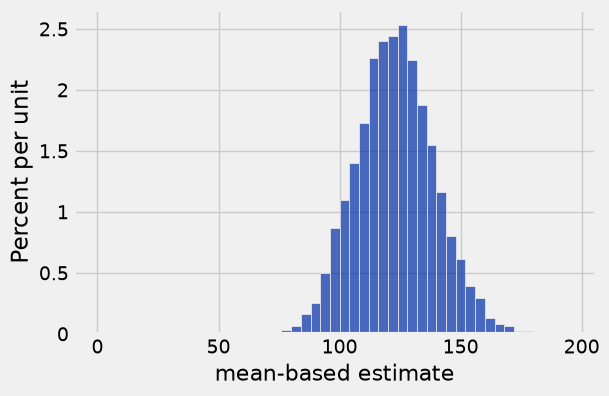

In [8]:
bootstrap_mean_based_estimates = sample_estimates(observations, mean_based_estimator, 5000)

# Don't change the code below! This plots bootstrap_mean_based_estimates.
Table().with_column("mean-based estimate", bootstrap_mean_based_estimates).hist(bins=np.arange(0, 200, 4)) 

`N` was actually 150! Does your distribution contain the true max value?

## 3. Computing intervals

**Question 3.1.** Compute an interval that covers the middle 95% of the mean-based bootstrap estimates.  Assign your values to `left_end_1` and `right_end_1`. 

Verify that your interval looks like it covers 95% of the area in the histogram. The red line on the histogram is the value of the parameter (150).

Middle 95% of bootstrap estimates: [92.823529, 155.529412]


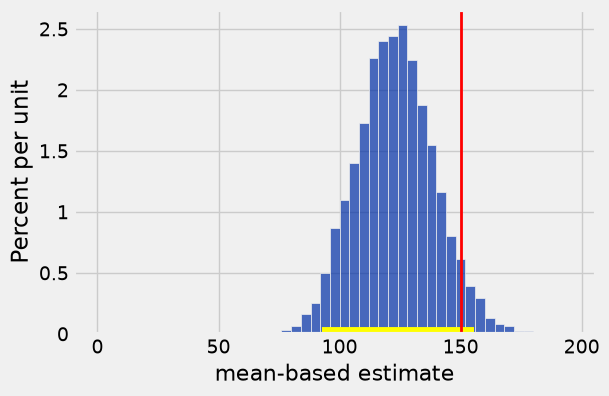

In [9]:
left_end_1 = np.percentile(bootstrap_mean_based_estimates, 2.5)
right_end_1 = np.percentile(bootstrap_mean_based_estimates, 97.5)
print("Middle 95% of bootstrap estimates: [{:f}, {:f}]".format(left_end_1, right_end_1))

# Don't change the code below! It draws your interval and N on the histogram of mean-based estimates.
Table().with_column("mean-based estimate", bootstrap_mean_based_estimates).hist(bins=np.arange(0, 200, 4)) 
plots.plot(make_array(left_end_1, right_end_1), make_array(0, 0), color='yellow', lw=10, zorder=1)
plots.axvline(150, color='red', lw=2, zorder=2);

## 4. Book Reviews

Your friend has recommended to you the book *Data Feminism* by D'Ignazio and Klein, so you decide to look at reviews for the book just to be sure that it's worth buying. On *Goodreads* the book has 1599 ratings, with 1351 of them at 4 stars or above (out of 5 stars).

**Question 4.1**. From this *Goodreads* sample simulate 5000 bootstrap resamples for the proportion of star ratings that are 4 or higher. For each bootstrap resample, calculate this proportion and store the resampled proportions in an array called `resample_star_props`. Then, plot a histogram of the resampled proportions.

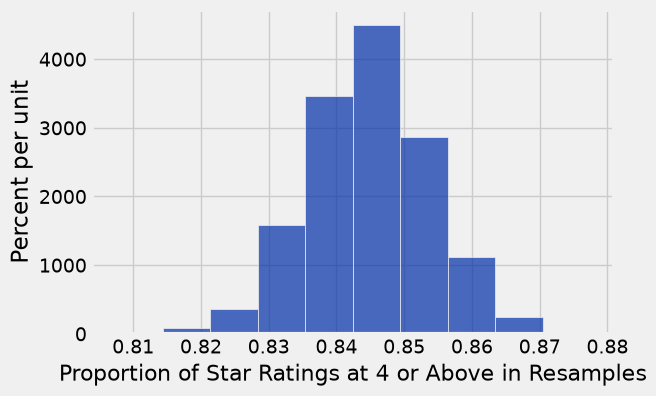

In [10]:
goodreads_ratings = np.append(np.ones(1351), np.zeros(1599 - 1351))
resample_star_props = make_array()

for i in np.arange(5000):
    resample = np.random.choice(goodreads_ratings, size=1599, replace=True)
    resample_star_props = np.append(resample_star_props, np.mean(resample))

# Do NOT change these lines.
Table().with_column("Proportion of Star Ratings at 4 or Above in Resamples", 
                     resample_star_props).hist("Proportion of Star Ratings at 4 or Above in Resamples")

**Question 4.2.** Compute an interval that covers the middle 90% of the bootstrap resamples of the proportion of star ratings that are 4 or higher.  Assign your values to `left_end_df` and `right_end_df`. Then plot the 90% confidence interval as a horizontal line on the given histogram.

Verify that your interval looks like it covers 90% of the area in the histogram.

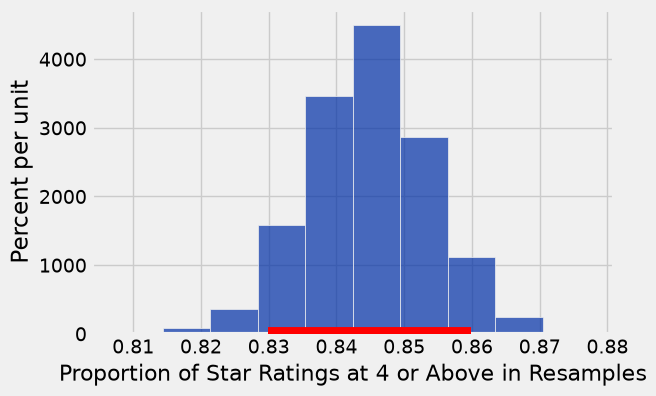

In [11]:
left_end_df = np.percentile(resample_star_props, 5)
right_end_df = np.percentile(resample_star_props, 95)

Table().with_column("Proportion of Star Ratings at 4 or Above in Resamples", 
                     resample_star_props).hist("Proportion of Star Ratings at 4 or Above in Resamples")
#overlay a horizontal line representing the confidence interval on the histogram
plots.plot(make_array(left_end_df, right_end_df), make_array(0, 0), color='red', lw=10, zorder=3)

**Question 4.3.** On Amazon, *Data Feminism* by D'Ignazio and Klein has only 286 ratings, with 275 of those ratings at 4 stars or higher. Repeat the process from the previous two questions and simulate 5000 bootstrap resamples of the proportion of star ratings that are 4 or higher using the *Amazon* sample. For each bootstrap resample, calculate this proportion and store the resampled proportions in an array called `resample_star_props_Amazon`. Then compute an interval that covers the middle 90% of the bootstrap resamples of the proportion of star ratings that are 4 or higher.  Assign your values to `left_end_df_Amazon` and `right_end_df_Amazon`. Then plot the 90% confidence interval as a horizontal line on the given histogram.

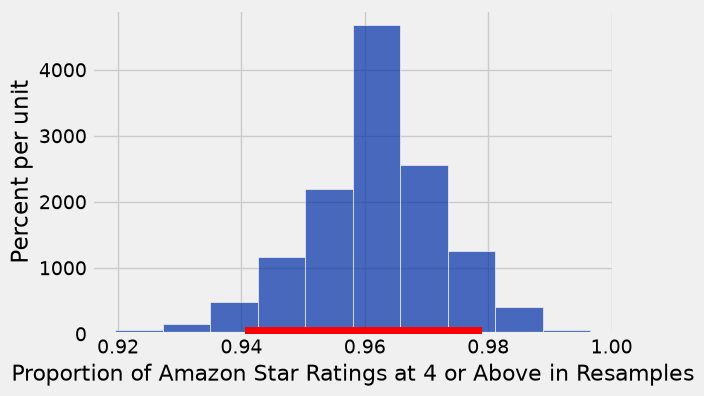

In [12]:
amazon_ratings = np.append(np.ones(275), np.zeros(286 - 275))
resample_star_props_Amazon = make_array()

for i in np.arange(5000):
    resample = np.random.choice(amazon_ratings, size=286, replace=True)
    resample_star_props_Amazon = np.append(resample_star_props_Amazon, np.mean(resample))

left_end_df_Amazon = np.percentile(resample_star_props_Amazon, 5)
right_end_df_Amazon = np.percentile(resample_star_props_Amazon, 95)
Table().with_column("Proportion of Amazon Star Ratings at 4 or Above in Resamples", 
                    resample_star_props_Amazon).hist("Proportion of Amazon Star Ratings at 4 or Above in Resamples")

#overlay a horizontal line representing the confidence interval on the histogram
plots.plot(make_array(left_end_df_Amazon, right_end_df_Amazon), make_array(0, 0), color='red', lw=10, zorder=3)

**Question 4.4.** Comment on the similarities or differences in the two confidence intervals constructed from the *Goodreads* ratings and the *Amazon* ratings as well as the factors that lead to these similarities and differences.

Both confidence intervals are 90% bootstrap intervals for the same quantity, the proportion of star ratings that are 4 or higher, and they are constructed in exactly the same way: 5000 bootstrap resamples followed by the 5th and 95th percentiles. Both are fairly narrow, each about 3 to 4 percentage points wide, and both lie entirely above 0.80, so on both platforms the book is rated highly on average.

The main difference is their location: the Amazon interval (roughly [0.94, 0.98]) sits entirely above the Goodreads interval (roughly [0.83, 0.86]), with no overlap, because the observed proportions are quite different - 275/286 = 96.1% on Amazon versus 1351/1599 = 84.5% on Goodreads. The Amazon interval is also slightly wider (margin of error about 0.019 versus 0.015), even though its proportion is closer to 1, because its sample size is much smaller (286 ratings versus 1599).

The factors behind these similarities and differences are (1) the observed sample proportion, which determines the center of each interval, and (2) the sample size n together with the standard error sqrt(p_hat(1 - p_hat)/n), which determines the width: a larger sample gives a narrower, more precise interval. Because the two intervals do not overlap, the difference in ratings between the platforms is larger than sampling variability alone would produce, suggesting that the two platforms' raters genuinely rate the book differently. Note also that each interval only describes sampling variability within its own platform, and bootstrapping relies on having a large, random sample, so the smaller Amazon sample makes its interval less stable than the Goodreads one.